# HDBSCAN parameter stability pipeline


In [1]:
import pandas as pd
from pathlib import Path
import sys

from transformers import AutoTokenizer

sys.path.append("./cluster_anlys")

from pca_hdbscan import run_pca_hdbscan_grid
from kondrak_cluster_morphology import (
    run_kondrak_morphology_for_partition,
    concat_global_summary_rows,
)
from script_entropy import (
    run_script_entropy_over_pca_dims,
    save_single_partition_outputs,
)
from spearman import (
    load_full_morphology_summary,
    load_full_script_summary,
    standardize_morphology_summary_df,
    standardize_script_summary_df,
    compare_seed_to_baseline_for_metric,
    compare_seed_to_baseline_joint_mean,
    save_spearman_summary_df,
)


## Configuration


In [25]:
BASELINE_OUT_ROOT = "comp"
STABILITY_ROOT = "stability"
SPACE_NAME = "output_proj"

L2_NORM = True
METRIC = "euclidean"
CLUSTER_SELECTION_METHOD = "eom"
CLUSTER_SELECTION_EPSILON = 0.0
N_PERMUTATIONS = 5000
RANDOM_STATE = 0

STABILITY_PARAM_CONFIGS = [
    {
        "min_cluster_size": 6,
        "min_samples": 5,
    },
    {
        "min_cluster_size": 5,
        "min_samples": 6,
    },
    {
        "min_cluster_size": 4,
        "min_samples": 5,
    },
    {
        "min_cluster_size": 5,
        "min_samples": 4,
    },
    {
        "min_cluster_size": 6,
        "min_samples": 6,
    },
    {
        "min_cluster_size": 4,
        "min_samples": 4,
    },
]

MODEL_RUN_CONFIGS = [
    {
        "label": "mistral",
        "model_name": "mistralai/Mistral-7B-v0.1",
        "tokenizer_path": "mistralai/Mistral-7B-v0.1/tokenizer",
        "full_pca_dim": 4096,
        "candidate_dims": [5, 142, 997, 2084, 3031, 3459, 3938, 4088, 4096],
    },
    {
        "label": "mixtral",
        "model_name": "mistralai/Mixtral-8x7B-v0.1",
        "tokenizer_path": "mistralai/Mixtral-8x7B-v0.1/tokenizer",
        "full_pca_dim": 4096,
        "candidate_dims": [8, 158, 1111, 2156, 3052, 3457, 3957, 4093, 4096],
    },
    {
        "label": "gpt-oss",
        "model_name": "gpt-oss",
        "tokenizer_path": "gpt-oss/tokenizer",
        "full_pca_dim": 2880,
        "candidate_dims": [6, 182, 466, 739, 1591, 2264, 2532, 2868, 2880],
    },
]


## Helpers


In [17]:
def make_stability_param_tag(param_config):
    return f"mcs={int(param_config['min_cluster_size'])}_ms={int(param_config['min_samples'])}"


def stability_out_root_for_config(param_config):
    return Path(STABILITY_ROOT) / make_stability_param_tag(param_config)


def ensure_full_pca_link(*, stability_out_root, model_name):
    source_dir = Path(BASELINE_OUT_ROOT) / model_name / "full_pca"
    target_dir = Path(stability_out_root) / model_name / "full_pca"

    if not source_dir.exists():
        raise FileNotFoundError(f"Full PCA source not found: {source_dir}")

    if target_dir.exists() or target_dir.is_symlink():
        return target_dir

    target_dir.parent.mkdir(parents=True, exist_ok=True)
    target_dir.symlink_to(source_dir.resolve(), target_is_directory=True)
    return target_dir


def hdbscan_params_from_stability_config(param_config):
    return {
        "min_cluster_size": int(param_config["min_cluster_size"]),
        "min_samples": int(param_config["min_samples"]),
        "metric": METRIC,
        "cluster_selection_method": CLUSTER_SELECTION_METHOD,
        "cluster_selection_epsilon": CLUSTER_SELECTION_EPSILON,
    }


In [18]:
def run_stability_hdbscan_for_model(*, model_config, param_config):
    stability_out_root = stability_out_root_for_config(param_config)
    ensure_full_pca_link(
        stability_out_root=stability_out_root,
        model_name=model_config["model_name"],
    )

    hdbscan_param_grid = [hdbscan_params_from_stability_config(param_config)]

    return run_pca_hdbscan_grid(
        candidate_dims=model_config["candidate_dims"],
        hdbscan_param_grid=hdbscan_param_grid,
        model_name=model_config["model_name"],
        space_name=SPACE_NAME,
        full_pca_dim=model_config["full_pca_dim"],
        out_root=str(stability_out_root),
        l2_norm=L2_NORM,
        summary_filename="summary.csv",
    )


def run_stability_morphology_for_model(*, model_config, param_config):
    stability_out_root = stability_out_root_for_config(param_config)
    hdbscan_params = hdbscan_params_from_stability_config(param_config)
    tokenizer = AutoTokenizer.from_pretrained(model_config["tokenizer_path"])
    global_rows = []

    for pca_dim in model_config["candidate_dims"]:
        cluster_outpath = (
            stability_out_root
            / model_config["model_name"]
            / SPACE_NAME
            / "morph"
            / f"kondrak_clusters_pca_{int(pca_dim)}.csv"
        )
        cluster_outpath.parent.mkdir(parents=True, exist_ok=True)

        _, global_row = run_kondrak_morphology_for_partition(
            out_root=str(stability_out_root),
            model_name=model_config["model_name"],
            space_name=SPACE_NAME,
            pca_dim=int(pca_dim),
            l2_norm=L2_NORM,
            min_cluster_size=hdbscan_params["min_cluster_size"],
            min_samples=hdbscan_params["min_samples"],
            metric=hdbscan_params["metric"],
            cluster_selection_method=hdbscan_params["cluster_selection_method"],
            cluster_selection_epsilon=hdbscan_params["cluster_selection_epsilon"],
            token_col="token_str",
            cluster_id_col="cluster_id",
            ddof=0,
            print_columns=False,
            save_cluster_csv=True,
            tokenizer=tokenizer,
            cluster_csv_outpath=cluster_outpath,
        )
        global_rows.append(global_row)

    summary_df = concat_global_summary_rows(global_rows)
    summary_outpath = stability_out_root / model_config["model_name"] / SPACE_NAME / "kondrak_global_summary.csv"
    summary_outpath.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(summary_outpath, index=False)
    print(f"Saved morphology summary -> {summary_outpath}")
    return summary_df


def run_stability_script_entropy_for_model(*, model_config, param_config):
    stability_out_root = stability_out_root_for_config(param_config)
    hdbscan_params = hdbscan_params_from_stability_config(param_config)
    tokenizer = AutoTokenizer.from_pretrained(model_config["tokenizer_path"])

    batch_result = run_script_entropy_over_pca_dims(
        out_root=str(stability_out_root),
        model_name=model_config["model_name"],
        space_name=SPACE_NAME,
        pca_dim_list=model_config["candidate_dims"],
        l2_norm=L2_NORM,
        min_cluster_size=hdbscan_params["min_cluster_size"],
        min_samples=hdbscan_params["min_samples"],
        metric=hdbscan_params["metric"],
        cluster_selection_method=hdbscan_params["cluster_selection_method"],
        cluster_selection_epsilon=hdbscan_params["cluster_selection_epsilon"],
        tokenizer=tokenizer,
        print_columns_first_only=True,
    )

    summary_df = batch_result["summary_df"]
    summary_outpath = stability_out_root / model_config["model_name"] / SPACE_NAME / "script_entropy_summary.csv"
    summary_outpath.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(summary_outpath, index=False)
    print(f"Saved script entropy summary -> {summary_outpath}")

    for pca_dim, result in batch_result["per_partition_results"].items():
        out_dir = (
            stability_out_root
            / model_config["model_name"]
            / SPACE_NAME
            / "script_entropy"
            / f"pca_{int(pca_dim)}"
        )
        save_single_partition_outputs(result=result, out_dir=out_dir)

    return summary_df


In [19]:
def run_stability_vs_full_spearman(*, param_config):
    stability_out_root = stability_out_root_for_config(param_config)
    hdbscan_params = hdbscan_params_from_stability_config(param_config)
    rows = []

    for model_config in MODEL_RUN_CONFIGS:
        baseline_morph = standardize_morphology_summary_df(
            load_full_morphology_summary(
                out_root=BASELINE_OUT_ROOT,
                model_name=model_config["model_name"],
                space_name=SPACE_NAME,
            ),
            df_name="baseline_morphology_summary",
        )
        stability_morph = standardize_morphology_summary_df(
            load_full_morphology_summary(
                out_root=str(stability_out_root),
                model_name=model_config["model_name"],
                space_name=SPACE_NAME,
            ),
            df_name="stability_morphology_summary",
        )
        baseline_script = standardize_script_summary_df(
            load_full_script_summary(
                out_root=BASELINE_OUT_ROOT,
                model_name=model_config["model_name"],
                space_name=SPACE_NAME,
            ),
            df_name="baseline_script_summary",
        )
        stability_script = standardize_script_summary_df(
            load_full_script_summary(
                out_root=str(stability_out_root),
                model_name=model_config["model_name"],
                space_name=SPACE_NAME,
            ),
            df_name="stability_script_summary",
        )

        morph_result = compare_seed_to_baseline_for_metric(
            baseline_morph,
            stability_morph,
            metric_family="morph",
            seed=0,
            n_permutations=N_PERMUTATIONS,
            random_state=RANDOM_STATE,
        )
        script_result = compare_seed_to_baseline_for_metric(
            baseline_script,
            stability_script,
            metric_family="script",
            seed=0,
            n_permutations=N_PERMUTATIONS,
            random_state=RANDOM_STATE,
        )
        joint_result = compare_seed_to_baseline_joint_mean(
            baseline_morph,
            stability_morph,
            baseline_script,
            stability_script,
            seed=0,
            n_permutations=N_PERMUTATIONS,
            random_state=RANDOM_STATE,
        )

        rows.append({
            "param_tag": make_stability_param_tag(param_config),
            "model_name": model_config["model_name"],
            "min_cluster_size": hdbscan_params["min_cluster_size"],
            "min_samples": hdbscan_params["min_samples"],
            "metric": hdbscan_params["metric"],
            "cluster_selection_method": hdbscan_params["cluster_selection_method"],
            "cluster_selection_epsilon": hdbscan_params["cluster_selection_epsilon"],
            "l2_norm": L2_NORM,
            "n_dims_morph": morph_result["n_dims"],
            "morph_mean_rho": morph_result["mean_rho"],
            "morph_mean_p": morph_result["mean_p"],
            "morph_std_rho": morph_result["std_rho"],
            "morph_std_p": morph_result["std_p"],
            "morph_mean_std_joint_rho": morph_result["mean_std_joint_rho"],
            "morph_mean_std_joint_perm_p": morph_result["mean_std_joint_perm_p"],
            "n_dims_script": script_result["n_dims"],
            "script_mean_rho": script_result["mean_rho"],
            "script_mean_p": script_result["mean_p"],
            "script_std_rho": script_result["std_rho"],
            "script_std_p": script_result["std_p"],
            "script_mean_std_joint_rho": script_result["mean_std_joint_rho"],
            "script_mean_std_joint_perm_p": script_result["mean_std_joint_perm_p"],
            "joint_mean_rho": joint_result["joint_mean_rho"],
            "joint_mean_perm_p": joint_result["joint_mean_perm_p"],
            "joint_mean_n_permutations": joint_result["joint_mean_n_permutations"],
        })

    summary_df = pd.DataFrame(rows)
    outpath = stability_out_root / "stability_vs_full_spearman.csv"
    save_spearman_summary_df(summary_df, outpath)
    print(f"Saved stability Spearman summary -> {outpath}")
    return summary_df


## Run stability pipeline


In [20]:
stability_spearman_results = []

for param_config in STABILITY_PARAM_CONFIGS:
    param_tag = make_stability_param_tag(param_config)
    print(f"\n==============================")
    print(f"Running stability config: {param_tag}")
    print(f"==============================")

    for model_config in MODEL_RUN_CONFIGS:
        print(f"\n--- HDBSCAN: {model_config['model_name']} | {param_tag} ---")
        run_stability_hdbscan_for_model(
            model_config=model_config,
            param_config=param_config,
        )

        print(f"\n--- Morphology: {model_config['model_name']} | {param_tag} ---")
        run_stability_morphology_for_model(
            model_config=model_config,
            param_config=param_config,
        )

        print(f"\n--- Script entropy: {model_config['model_name']} | {param_tag} ---")
        run_stability_script_entropy_for_model(
            model_config=model_config,
            param_config=param_config,
        )

    print(f"\n--- Spearman stability vs full | {param_tag} ---")
    spearman_df = run_stability_vs_full_spearman(param_config=param_config)
    stability_spearman_results.append(spearman_df)

all_stability_spearman_df = pd.concat(stability_spearman_results, axis=0, ignore_index=True)
all_stability_spearman_outpath = Path(STABILITY_ROOT) / "stability_vs_full_spearman_all_configs.csv"
all_stability_spearman_outpath.parent.mkdir(parents=True, exist_ok=True)
all_stability_spearman_df.to_csv(all_stability_spearman_outpath, index=False)
print(f"Saved all-config stability Spearman summary -> {all_stability_spearman_outpath}")
all_stability_spearman_df



Running stability config: mcs=6_ms=5

--- HDBSCAN: mistralai/Mistral-7B-v0.1 | mcs=6_ms=5 ---
[i] Loaded PCA from: stability/mcs=6_ms=5/mistralai/Mistral-7B-v0.1/full_pca
[i] PCA mode: full
[i] PCA shape: (32000, 4096)
[i] Candidate dims: [5, 142, 997, 2084, 3031, 3459, 3938, 4088, 4096]
[i] Number of HDBSCAN configs: 1

[i] Run 00001 | pca_mode=full dim=5 params={'min_cluster_size': 6, 'min_samples': 5, 'metric': 'euclidean', 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.0}
[i] HDBSCAN params | min_cluster_size=6, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-06-05 13:07:41.641] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
[✓] cuML HDBSCAN finished (0.45s)
[✓] CSV  → stability/mcs=6_ms=5/mistralai/Mistral-7B-v0.1/output_proj/clusters_l2=True/run_00001_clusters.csv
[✓] META → stability/mcs=6_ms=5/mistralai/Mistral-7B-v0.1/output_proj/meta_l2=True/run_00001_meta.json

[i] Run 00002 | pc

,param_tag,model_name,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,l2_norm,n_dims_morph,morph_mean_rho,...,n_dims_script,script_mean_rho,script_mean_p,script_std_rho,script_std_p,script_mean_std_joint_rho,script_mean_std_joint_perm_p,joint_mean_rho,joint_mean_perm_p,joint_mean_n_permutations
0,mcs=6_ms=5,mistralai/Mistral-7B-v0.1,6,5,euclidean,eom,0.0,True,9,0.983333,...,9,0.966667,0.000022,1.000000,0.000000,0.995872,0.000200,0.993808,0.000200,5000
1,mcs=6_ms=5,mistralai/Mixtral-8x7B-v0.1,6,5,euclidean,eom,0.0,True,9,0.850000,...,9,0.983333,0.000002,1.000000,0.000000,0.997936,0.000200,0.830753,0.000200,5000
2,mcs=5_ms=6,mistralai/Mistral-7B-v0.1,5,6,euclidean,eom,0.0,True,9,0.950000,...,9,0.566667,0.111633,0.833333,0.005266,0.925697,0.002200,0.940144,0.001000,5000
3,mcs=5_ms=6,mistralai/Mixtral-8x7B-v0.1,5,6,euclidean,eom,0.0,True,9,0.683333,...,9,0.800000,0.009628,0.533333,0.139227,0.911249,0.004399,0.576883,0.015997,5000
4,mcs=4_ms=5,mistralai/Mistral-7B-v0.1,4,5,euclidean,eom,0.0,True,9,0.850000,...,9,1.000000,0.000000,1.000000,0.000000,1.000000,0.000200,0.960784,0.000200,5000
5,mcs=4_ms=5,mistralai/Mixtral-8x7B-v0.1,4,5,euclidean,eom,0.0,True,9,0.583333,...,9,0.900000,0.000943,0.950000,0.000088,0.981424,0.000200,0.343653,0.157768,5000
6,mcs=5_ms=4,mistralai/Mistral-7B-v0.1,5,4,euclidean,eom,0.0,True,9,0.983333,...,9,0.866667,0.002495,0.700000,0.035770,0.944272,0.001400,0.979360,0.000200,5000
7,mcs=5_ms=4,mistralai/Mixtral-8x7B-v0.1,5,4,euclidean,eom,0.0,True,9,0.433333,...,9,1.000000,0.000000,0.533333,0.139227,0.942208,0.000600,0.597523,0.001400,5000
8,mcs=6_ms=6,mistralai/Mistral-7B-v0.1,6,6,euclidean,eom,0.0,True,9,0.933333,...,9,0.500000,0.170471,0.766667,0.015944,0.909185,0.005799,0.929825,0.001200,5000
9,mcs=6_ms=6,mistralai/Mixtral-8x7B-v0.1,6,6,euclidean,eom,0.0,True,9,0.733333,...,9,0.650000,0.058073,0.283333,0.460030,0.857585,0.020796,0.678019,0.000600,5000


In [21]:
def print_stability_spearman_results():
    display_cols = [
        "param_tag",
        "model_name",
        "morph_mean_rho",
        "morph_mean_p",
        "morph_std_rho",
        "morph_std_p",
        "script_mean_rho",
        "script_mean_p",
        "script_std_rho",
        "script_std_p",
        "joint_mean_rho",
        "joint_mean_perm_p",
    ]
    frames = []

    for param_config in STABILITY_PARAM_CONFIGS:
        param_tag = make_stability_param_tag(param_config)
        spearman_path = Path(STABILITY_ROOT) / param_tag / "stability_vs_full_spearman.csv"
        print(f"\n=== {param_tag} ===")

        if not spearman_path.exists():
            print(f"Missing Spearman file: {spearman_path}")
            continue

        spearman_df = pd.read_csv(spearman_path)
        frames.append(spearman_df)

        for model_config in MODEL_RUN_CONFIGS:
            model_name = model_config["model_name"]
            model_rows = spearman_df.loc[spearman_df["model_name"] == model_name]

            if model_rows.empty:
                print(f"{model_name}: missing")
                continue

            row = model_rows.iloc[0]
            print(
                f"{model_name}: "
                f"morph_mean_rho={row['morph_mean_rho']:.6g}, "
                f"morph_std_rho={row['morph_std_rho']:.6g}, "
                f"script_mean_rho={row['script_mean_rho']:.6g}, "
                f"script_std_rho={row['script_std_rho']:.6g}, "
                f"joint_mean_rho={row['joint_mean_rho']:.6g}"
            )

    if not frames:
        return pd.DataFrame(columns=display_cols)

    combined_df = pd.concat(frames, axis=0, ignore_index=True)
    combined_df = combined_df.loc[:, [col for col in display_cols if col in combined_df.columns]]
    return combined_df

In [22]:
stability_spearman_report_df = print_stability_spearman_results()
stability_spearman_report_df



=== mcs=6_ms=5 ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.983333, morph_std_rho=0.2, script_mean_rho=0.966667, script_std_rho=1, joint_mean_rho=0.993808
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.85, morph_std_rho=0.833333, script_mean_rho=0.983333, script_std_rho=1, joint_mean_rho=0.830753

=== mcs=5_ms=6 ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.95, morph_std_rho=0.783333, script_mean_rho=0.566667, script_std_rho=0.833333, joint_mean_rho=0.940144
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.683333, morph_std_rho=0.783333, script_mean_rho=0.8, script_std_rho=0.533333, joint_mean_rho=0.576883

=== mcs=4_ms=5 ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.85, morph_std_rho=0.2, script_mean_rho=1, script_std_rho=1, joint_mean_rho=0.960784
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.583333, morph_std_rho=0.8, script_mean_rho=0.9, script_std_rho=0.95, joint_mean_rho=0.343653

=== mcs=5_ms=4 ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.983333, morph_std_rho=0.3, script

,param_tag,model_name,morph_mean_rho,morph_mean_p,morph_std_rho,morph_std_p,script_mean_rho,script_mean_p,script_std_rho,script_std_p,joint_mean_rho,joint_mean_perm_p
0,mcs=6_ms=5,mistralai/Mistral-7B-v0.1,0.983333,0.000002,0.200000,0.605901,0.966667,0.000022,1.000000,0.000000,0.993808,0.000200
1,mcs=6_ms=5,mistralai/Mixtral-8x7B-v0.1,0.850000,0.003705,0.833333,0.005266,0.983333,0.000002,1.000000,0.000000,0.830753,0.000200
2,mcs=5_ms=6,mistralai/Mistral-7B-v0.1,0.950000,0.000088,0.783333,0.012520,0.566667,0.111633,0.833333,0.005266,0.940144,0.001000
3,mcs=5_ms=6,mistralai/Mixtral-8x7B-v0.1,0.683333,0.042442,0.783333,0.012520,0.800000,0.009628,0.533333,0.139227,0.576883,0.015997
4,mcs=4_ms=5,mistralai/Mistral-7B-v0.1,0.850000,0.003705,0.200000,0.605901,1.000000,0.000000,1.000000,0.000000,0.960784,0.000200
5,mcs=4_ms=5,mistralai/Mixtral-8x7B-v0.1,0.583333,0.099186,0.800000,0.009628,0.900000,0.000943,0.950000,0.000088,0.343653,0.157768
6,mcs=5_ms=4,mistralai/Mistral-7B-v0.1,0.983333,0.000002,0.300000,0.432845,0.866667,0.002495,0.700000,0.035770,0.979360,0.000200
7,mcs=5_ms=4,mistralai/Mixtral-8x7B-v0.1,0.433333,0.243952,0.833333,0.005266,1.000000,0.000000,0.533333,0.139227,0.597523,0.001400
8,mcs=6_ms=6,mistralai/Mistral-7B-v0.1,0.933333,0.000236,0.783333,0.012520,0.500000,0.170471,0.766667,0.015944,0.929825,0.001200
9,mcs=6_ms=6,mistralai/Mixtral-8x7B-v0.1,0.733333,0.024554,0.950000,0.000088,0.650000,0.058073,0.283333,0.460030,0.678019,0.000600


In [21]:
stability_spearman_report_df = print_stability_spearman_results()
stability_spearman_report_df



=== mcs=6_ms=5 ===
gpt-oss: morph_mean_rho=0.983333, morph_std_rho=1, script_mean_rho=0.816667, script_std_rho=1, joint_mean_rho=0.919505

=== mcs=5_ms=6 ===
gpt-oss: morph_mean_rho=1, morph_std_rho=0.833333, script_mean_rho=0.983333, script_std_rho=1, joint_mean_rho=0.933953

=== mcs=4_ms=5 ===
gpt-oss: morph_mean_rho=0.983333, morph_std_rho=0.7, script_mean_rho=0.983333, script_std_rho=1, joint_mean_rho=0.845201

=== mcs=5_ms=4 ===
gpt-oss: morph_mean_rho=1, morph_std_rho=0.35, script_mean_rho=0.816667, script_std_rho=0.983333, joint_mean_rho=0.599587


,param_tag,model_name,morph_mean_rho,morph_mean_p,morph_std_rho,morph_std_p,script_mean_rho,script_mean_p,script_std_rho,script_std_p,joint_mean_rho,joint_mean_perm_p
0,mcs=6_ms=5,gpt-oss,0.983333,0.000002,1.000000,0.000000,0.816667,0.007225,1.000000,0.000000,0.919505,0.000200
1,mcs=5_ms=6,gpt-oss,1.000000,0.000000,0.833333,0.005266,0.983333,0.000002,1.000000,0.000000,0.933953,0.000200
2,mcs=4_ms=5,gpt-oss,0.983333,0.000002,0.700000,0.035770,0.983333,0.000002,1.000000,0.000000,0.845201,0.000200
3,mcs=5_ms=4,gpt-oss,1.000000,0.000000,0.350000,0.355820,0.816667,0.007225,0.983333,0.000002,0.599587,0.002799


In [29]:
stability_spearman_report_df = print_stability_spearman_results()
stability_spearman_report_df



=== mcs=6_ms=5 ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.983333, morph_std_rho=0.2, script_mean_rho=0.966667, script_std_rho=1, joint_mean_rho=0.993808
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.85, morph_std_rho=0.833333, script_mean_rho=0.983333, script_std_rho=1, joint_mean_rho=0.830753
gpt-oss: missing

=== mcs=5_ms=6 ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.95, morph_std_rho=0.783333, script_mean_rho=0.566667, script_std_rho=0.833333, joint_mean_rho=0.940144
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.683333, morph_std_rho=0.783333, script_mean_rho=0.8, script_std_rho=0.533333, joint_mean_rho=0.576883
gpt-oss: missing

=== mcs=4_ms=5 ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.85, morph_std_rho=0.2, script_mean_rho=1, script_std_rho=1, joint_mean_rho=0.960784
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.583333, morph_std_rho=0.8, script_mean_rho=0.9, script_std_rho=0.95, joint_mean_rho=0.343653
gpt-oss: missing

=== mcs=5_ms=4 ===
mistralai/Mistral-7B-v0.1:

,param_tag,model_name,morph_mean_rho,morph_mean_p,morph_std_rho,morph_std_p,script_mean_rho,script_mean_p,script_std_rho,script_std_p,joint_mean_rho,joint_mean_perm_p
0,mcs=6_ms=5,mistralai/Mistral-7B-v0.1,0.983333,0.000002,0.200000,0.605901,0.966667,0.000022,1.000000,0.000000,0.993808,0.000200
1,mcs=6_ms=5,mistralai/Mixtral-8x7B-v0.1,0.850000,0.003705,0.833333,0.005266,0.983333,0.000002,1.000000,0.000000,0.830753,0.000200
2,mcs=5_ms=6,mistralai/Mistral-7B-v0.1,0.950000,0.000088,0.783333,0.012520,0.566667,0.111633,0.833333,0.005266,0.940144,0.001000
3,mcs=5_ms=6,mistralai/Mixtral-8x7B-v0.1,0.683333,0.042442,0.783333,0.012520,0.800000,0.009628,0.533333,0.139227,0.576883,0.015997
4,mcs=4_ms=5,mistralai/Mistral-7B-v0.1,0.850000,0.003705,0.200000,0.605901,1.000000,0.000000,1.000000,0.000000,0.960784,0.000200
5,mcs=4_ms=5,mistralai/Mixtral-8x7B-v0.1,0.583333,0.099186,0.800000,0.009628,0.900000,0.000943,0.950000,0.000088,0.343653,0.157768
6,mcs=5_ms=4,mistralai/Mistral-7B-v0.1,0.983333,0.000002,0.300000,0.432845,0.866667,0.002495,0.700000,0.035770,0.979360,0.000200
7,mcs=5_ms=4,mistralai/Mixtral-8x7B-v0.1,0.433333,0.243952,0.833333,0.005266,1.000000,0.000000,0.533333,0.139227,0.597523,0.001400
8,mcs=6_ms=6,mistralai/Mistral-7B-v0.1,0.933333,0.000236,0.783333,0.012520,0.500000,0.170471,0.766667,0.015944,0.929825,0.001200
9,mcs=6_ms=6,mistralai/Mixtral-8x7B-v0.1,0.733333,0.024554,0.950000,0.000088,0.650000,0.058073,0.283333,0.460030,0.678019,0.000600


In [22]:
from cluster_anlys.tool_fig import (
    load_morphology_summary,
    load_script_entropy_summary,
    merge_partition_summaries,
    plot_partition_level_morphology_vs_script_entropy,
    sanity_check_merged_partition_df,
    sanity_check_script_summary_uniqueness,
)


TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

In [23]:
def plot_stability_morphology_vs_script_entropy():
    plotted = []

    for param_config in STABILITY_PARAM_CONFIGS:
        param_tag = make_stability_param_tag(param_config)
        stability_out_root = stability_out_root_for_config(param_config)

        for model_config in MODEL_RUN_CONFIGS:
            model_name = model_config["model_name"]
            model_dir = stability_out_root / model_name / SPACE_NAME
            morphology_csv_path = model_dir / "kondrak_global_summary.csv"
            script_entropy_summary_path = model_dir / "script_entropy_summary.csv"

            print(f"\n=== {param_tag} | {model_name} ===")

            if not morphology_csv_path.exists():
                print(f"Missing morphology summary: {morphology_csv_path}")
                continue
            if not script_entropy_summary_path.exists():
                print(f"Missing script entropy summary: {script_entropy_summary_path}")
                continue

            morphology_df = load_morphology_summary(str(morphology_csv_path))
            script_df = load_script_entropy_summary(str(script_entropy_summary_path))
            sanity_check_script_summary_uniqueness(script_df)

            merged_df = merge_partition_summaries(
                morphology_df=morphology_df,
                script_df=script_df,
            )
            sanity_check_merged_partition_df(merged_df)

            plot_partition_level_morphology_vs_script_entropy(
                df=merged_df,
                model_name=f"{model_name} | {param_tag}",
                title_fontsize=TITLE_FONTSIZE,
                label_fontsize=LABEL_FONTSIZE,
                tick_fontsize=TICK_FONTSIZE,
            )
            plotted.append({
                "param_tag": param_tag,
                "model_name": model_name,
                "n_dims": int(merged_df["pca_dim"].nunique()),
            })

    return pd.DataFrame(plotted)



=== mcs=5_ms=6 | mistralai/Mistral-7B-v0.1 ===
Saved to: ./res/linguistic/mistralai_Mistral-7B-v0.1 | mcs=5_ms=6.pdf


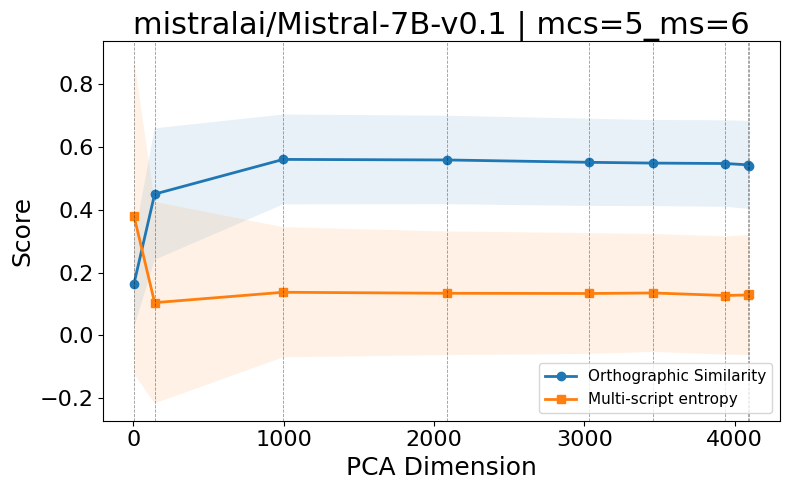


=== mcs=5_ms=6 | mistralai/Mixtral-8x7B-v0.1 ===
Saved to: ./res/linguistic/mistralai_Mixtral-8x7B-v0.1 | mcs=5_ms=6.pdf


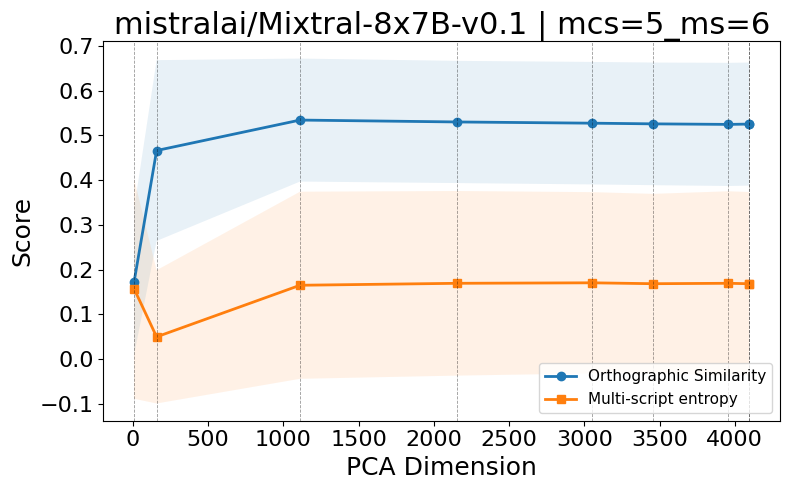


=== mcs=4_ms=5 | mistralai/Mistral-7B-v0.1 ===
Saved to: ./res/linguistic/mistralai_Mistral-7B-v0.1 | mcs=4_ms=5.pdf


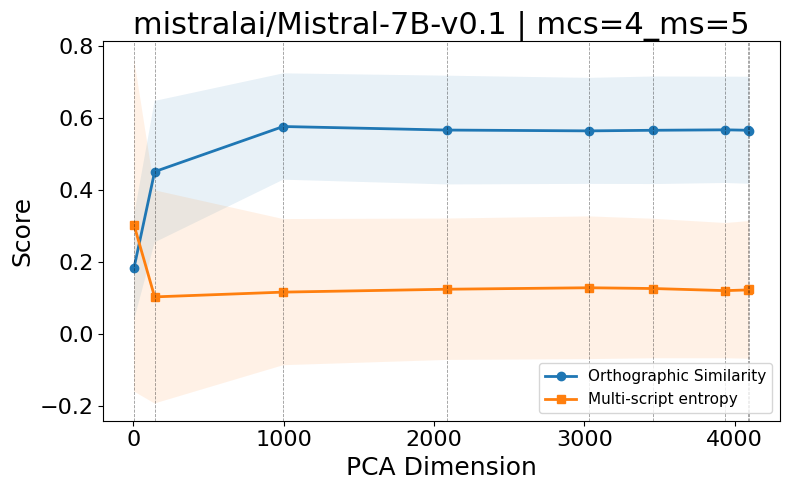


=== mcs=4_ms=5 | mistralai/Mixtral-8x7B-v0.1 ===
Saved to: ./res/linguistic/mistralai_Mixtral-8x7B-v0.1 | mcs=4_ms=5.pdf


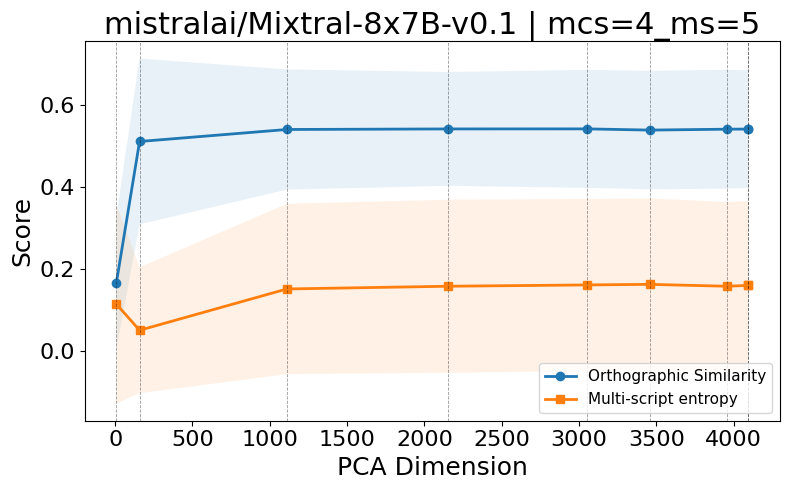


=== mcs=5_ms=4 | mistralai/Mistral-7B-v0.1 ===
Saved to: ./res/linguistic/mistralai_Mistral-7B-v0.1 | mcs=5_ms=4.pdf


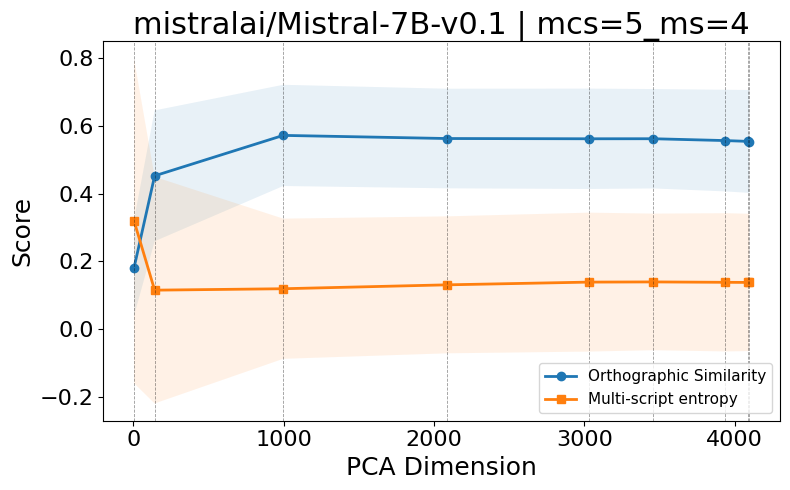


=== mcs=5_ms=4 | mistralai/Mixtral-8x7B-v0.1 ===
Saved to: ./res/linguistic/mistralai_Mixtral-8x7B-v0.1 | mcs=5_ms=4.pdf


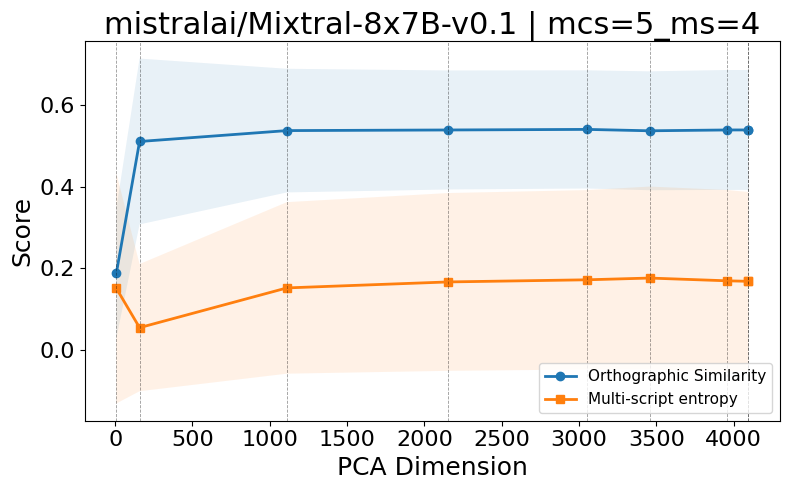

,param_tag,model_name,n_dims
0,mcs=5_ms=6,mistralai/Mistral-7B-v0.1,9
1,mcs=5_ms=6,mistralai/Mixtral-8x7B-v0.1,9
2,mcs=4_ms=5,mistralai/Mistral-7B-v0.1,9
3,mcs=4_ms=5,mistralai/Mixtral-8x7B-v0.1,9
4,mcs=5_ms=4,mistralai/Mistral-7B-v0.1,9
5,mcs=5_ms=4,mistralai/Mixtral-8x7B-v0.1,9


In [15]:

stability_morph_script_plot_df = plot_stability_morphology_vs_script_entropy()
stability_morph_script_plot_df



=== mcs=6_ms=5 | gpt-oss ===
Saved to: ./res/linguistic/gpt-oss | mcs=6_ms=5.pdf


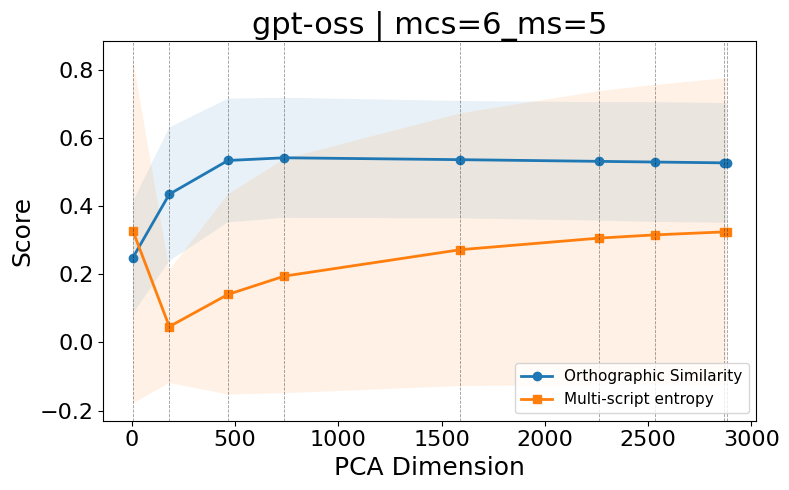


=== mcs=5_ms=6 | gpt-oss ===
Saved to: ./res/linguistic/gpt-oss | mcs=5_ms=6.pdf


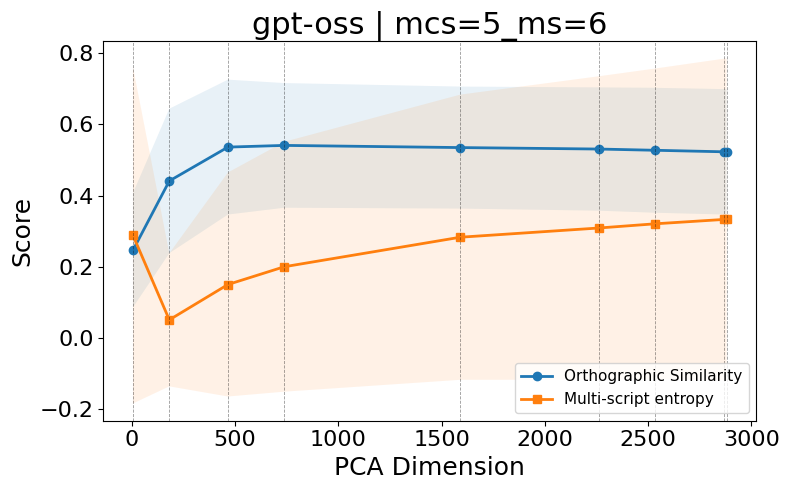


=== mcs=4_ms=5 | gpt-oss ===
Saved to: ./res/linguistic/gpt-oss | mcs=4_ms=5.pdf


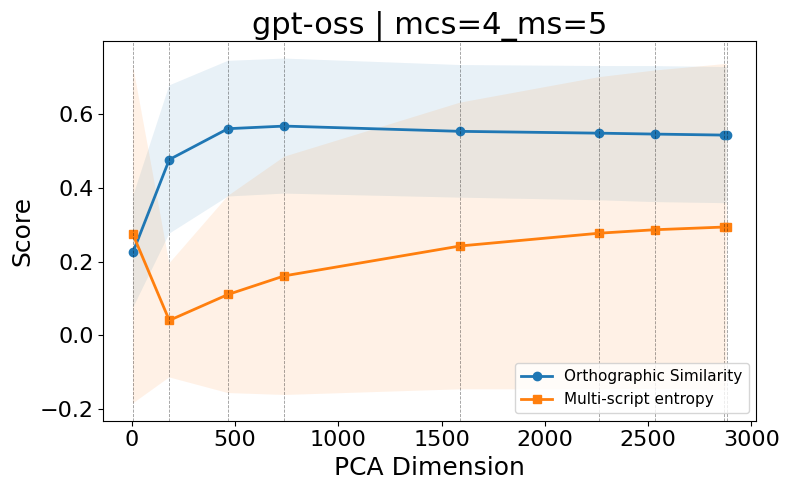


=== mcs=5_ms=4 | gpt-oss ===
Saved to: ./res/linguistic/gpt-oss | mcs=5_ms=4.pdf


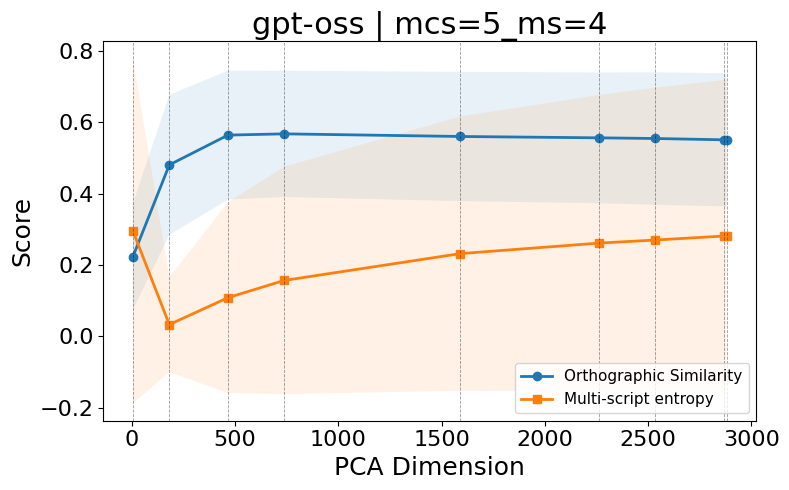

,param_tag,model_name,n_dims
0,mcs=6_ms=5,gpt-oss,9
1,mcs=5_ms=6,gpt-oss,9
2,mcs=4_ms=5,gpt-oss,9
3,mcs=5_ms=4,gpt-oss,9


In [24]:

stability_morph_script_plot_df = plot_stability_morphology_vs_script_entropy()
stability_morph_script_plot_df

In [26]:
def compute_curve_r2(baseline_values, stability_values):
    baseline_values = pd.Series(baseline_values, dtype=float).to_numpy()
    stability_values = pd.Series(stability_values, dtype=float).to_numpy()
    ss_res = float(((stability_values - baseline_values) ** 2).sum())
    ss_tot = float(((baseline_values - baseline_values.mean()) ** 2).sum())
    if ss_tot == 0.0:
        return float("nan")
    return 1.0 - ss_res / ss_tot


def compute_stability_curve_mae_report():
    rows = []

    for param_config in STABILITY_PARAM_CONFIGS:
        param_tag = make_stability_param_tag(param_config)
        stability_out_root = stability_out_root_for_config(param_config)

        print(f"\n=== {param_tag} ===")

        for model_config in MODEL_RUN_CONFIGS:
            model_name = model_config["model_name"]
            baseline_model_dir = Path(BASELINE_OUT_ROOT) / model_name / SPACE_NAME
            stability_model_dir = stability_out_root / model_name / SPACE_NAME

            baseline_morph_path = baseline_model_dir / "kondrak_global_summary.csv"
            baseline_script_path = baseline_model_dir / "script_entropy_summary.csv"
            stability_morph_path = stability_model_dir / "kondrak_global_summary.csv"
            stability_script_path = stability_model_dir / "script_entropy_summary.csv"

            required_paths = [
                baseline_morph_path,
                baseline_script_path,
                stability_morph_path,
                stability_script_path,
            ]
            missing_paths = [str(p) for p in required_paths if not p.exists()]
            if missing_paths:
                print(f"{model_name}: missing files")
                for missing_path in missing_paths:
                    print(f"  {missing_path}")
                continue

            baseline_morph = pd.read_csv(baseline_morph_path)
            baseline_script = pd.read_csv(baseline_script_path)
            stability_morph = pd.read_csv(stability_morph_path)
            stability_script = pd.read_csv(stability_script_path)

            morph_aligned = (
                baseline_morph[["pca_dim", "global_mean"]]
                .merge(
                    stability_morph[["pca_dim", "global_mean"]],
                    on="pca_dim",
                    how="inner",
                    suffixes=("_baseline", "_stability"),
                )
                .sort_values("pca_dim")
                .reset_index(drop=True)
            )
            script_aligned = (
                baseline_script[["pca_dim", "mean_H"]]
                .merge(
                    stability_script[["pca_dim", "mean_H"]],
                    on="pca_dim",
                    how="inner",
                    suffixes=("_baseline", "_stability"),
                )
                .sort_values("pca_dim")
                .reset_index(drop=True)
            )

            if morph_aligned.empty:
                raise ValueError(f"No overlapping morphology pca_dim values for {param_tag} | {model_name}")
            if script_aligned.empty:
                raise ValueError(f"No overlapping script pca_dim values for {param_tag} | {model_name}")

            morph_baseline_values = morph_aligned["global_mean_baseline"].to_numpy(dtype=float)
            morph_stability_values = morph_aligned["global_mean_stability"].to_numpy(dtype=float)
            script_baseline_values = script_aligned["mean_H_baseline"].to_numpy(dtype=float)
            script_stability_values = script_aligned["mean_H_stability"].to_numpy(dtype=float)

            morph_abs_errors = abs(morph_stability_values - morph_baseline_values)
            script_abs_errors = abs(script_stability_values - script_baseline_values)

            morph_mean_mae = float(morph_abs_errors.mean())
            script_mean_mae = float(script_abs_errors.mean())
            joint_mean_mae = float(pd.Series([*morph_abs_errors, *script_abs_errors]).mean())

            joint_baseline_values = pd.Series([*morph_baseline_values, *script_baseline_values], dtype=float).to_numpy()
            joint_stability_values = pd.Series([*morph_stability_values, *script_stability_values], dtype=float).to_numpy()
            morph_mean_r2 = compute_curve_r2(morph_baseline_values, morph_stability_values)
            script_mean_r2 = compute_curve_r2(script_baseline_values, script_stability_values)
            joint_mean_r2 = compute_curve_r2(joint_baseline_values, joint_stability_values)

            print(
                f"{model_name}: "
                f"morph_mean_mae={morph_mean_mae:.6g}, "
                f"script_mean_mae={script_mean_mae:.6g}, "
                f"joint_mean_mae={joint_mean_mae:.6g}, "
                f"morph_mean_r2={morph_mean_r2:.6g}, "
                f"script_mean_r2={script_mean_r2:.6g}, "
                f"joint_mean_r2={joint_mean_r2:.6g}"
            )

            rows.append({
                "param_tag": param_tag,
                "model_name": model_name,
                "min_cluster_size": int(param_config["min_cluster_size"]),
                "min_samples": int(param_config["min_samples"]),
                "n_dims_morph": int(len(morph_aligned)),
                "n_dims_script": int(len(script_aligned)),
                "morph_mean_mae": morph_mean_mae,
                "script_mean_mae": script_mean_mae,
                "joint_mean_mae": joint_mean_mae,
                "morph_mean_r2": morph_mean_r2,
                "script_mean_r2": script_mean_r2,
                "joint_mean_r2": joint_mean_r2,
            })

    return pd.DataFrame(rows)


In [27]:
stability_curve_mae_df = compute_stability_curve_mae_report()
stability_curve_mae_df


=== mcs=6_ms=5 ===
mistralai/Mistral-7B-v0.1: morph_mean_mae=0.0123741, script_mean_mae=0.0109294, joint_mean_mae=0.0116517, morph_mean_r2=0.988354, script_mean_r2=0.955855, joint_mean_r2=0.995784
mistralai/Mixtral-8x7B-v0.1: morph_mean_mae=0.0107033, script_mean_mae=0.0101888, joint_mean_mae=0.010446, morph_mean_r2=0.990404, script_mean_r2=0.874338, joint_mean_r2=0.995862
gpt-oss: morph_mean_mae=0.0114161, script_mean_mae=0.0157877, joint_mean_mae=0.0136019, morph_mean_r2=0.983571, script_mean_r2=0.958557, joint_mean_r2=0.990403

=== mcs=5_ms=6 ===
mistralai/Mistral-7B-v0.1: morph_mean_mae=0.00848919, script_mean_mae=0.0102262, joint_mean_mae=0.00935769, morph_mean_r2=0.992048, script_mean_r2=0.905874, joint_mean_r2=0.993948
mistralai/Mixtral-8x7B-v0.1: morph_mean_mae=0.00610015, script_mean_mae=0.00691848, joint_mean_mae=0.00650931, morph_mean_r2=0.992476, script_mean_r2=0.944731, joint_mean_r2=0.997547
gpt-oss: morph_mean_mae=0.0117605, script_mean_mae=0.0178612, joint_mean_mae=0.0

,param_tag,model_name,min_cluster_size,min_samples,n_dims_morph,n_dims_script,morph_mean_mae,script_mean_mae,joint_mean_mae,morph_mean_r2,script_mean_r2,joint_mean_r2
0,mcs=6_ms=5,mistralai/Mistral-7B-v0.1,6,5,9,9,0.012374,0.010929,0.011652,0.988354,0.955855,0.995784
1,mcs=6_ms=5,mistralai/Mixtral-8x7B-v0.1,6,5,9,9,0.010703,0.010189,0.010446,0.990404,0.874338,0.995862
2,mcs=6_ms=5,gpt-oss,6,5,9,9,0.011416,0.015788,0.013602,0.983571,0.958557,0.990403
3,mcs=5_ms=6,mistralai/Mistral-7B-v0.1,5,6,9,9,0.008489,0.010226,0.009358,0.992048,0.905874,0.993948
4,mcs=5_ms=6,mistralai/Mixtral-8x7B-v0.1,5,6,9,9,0.006100,0.006918,0.006509,0.992476,0.944731,0.997547
5,mcs=5_ms=6,gpt-oss,5,6,9,9,0.011760,0.017861,0.014811,0.984945,0.956357,0.990309
6,mcs=4_ms=5,mistralai/Mistral-7B-v0.1,4,5,9,9,0.011954,0.011184,0.011569,0.988617,0.963328,0.996200
7,mcs=4_ms=5,mistralai/Mixtral-8x7B-v0.1,4,5,9,9,0.012121,0.014565,0.013343,0.987297,0.811341,0.994114
8,mcs=4_ms=5,gpt-oss,4,5,9,9,0.011367,0.014185,0.012776,0.984663,0.972358,0.992788
9,mcs=5_ms=4,mistralai/Mistral-7B-v0.1,5,4,9,9,0.007467,0.005614,0.006541,0.994550,0.986938,0.998404


In [10]:
def compute_stability_metric_means_by_model(stability_metric_df):
    if stability_metric_df.empty:
        return pd.DataFrame()

    value_cols = [
        "morph_mean_mae",
        "script_mean_mae",
        "joint_mean_mae",
        "morph_mean_r2",
        "script_mean_r2",
        "joint_mean_r2",
    ]
    available_value_cols = [col for col in value_cols if col in stability_metric_df.columns]
    if not available_value_cols:
        raise ValueError("No stability metric columns are available for averaging.")

    mean_df = (
        stability_metric_df
        .groupby("model_name", as_index=False)[available_value_cols]
        .mean()
    )

    count_df = (
        stability_metric_df
        .groupby("model_name", as_index=False)
        .size()
        .rename(columns={"size": "n_param_configs"})
    )

    mean_df = count_df.merge(mean_df, on="model_name", how="inner")
    return mean_df



In [11]:
stability_metric_mean_by_model_df = compute_stability_metric_means_by_model(
    stability_curve_mae_df
)
stability_metric_mean_by_model_df

,model_name,n_param_configs,morph_mean_mae,script_mean_mae,joint_mean_mae,morph_mean_r2,script_mean_r2,joint_mean_r2
0,gpt-oss,6,0.016479,0.022307,0.019393,0.965502,0.923453,0.981504
1,mistralai/Mistral-7B-v0.1,6,0.012630,0.011038,0.011834,0.984458,0.915122,0.993086
2,mistralai/Mixtral-8x7B-v0.1,6,0.012999,0.010216,0.011608,0.981324,0.878134,0.994190


In [28]:
def compute_stability_spearman_means_by_model():
    metric_cols = [
        "morph_mean_rho",
        "morph_mean_p",
        "morph_std_rho",
        "morph_std_p",
        "script_mean_rho",
        "script_mean_p",
        "script_std_rho",
        "script_std_p",
        "joint_mean_rho",
        "joint_mean_perm_p",
    ]
    rows = []

    for param_config in STABILITY_PARAM_CONFIGS:
        param_tag = make_stability_param_tag(param_config)
        spearman_path = Path(STABILITY_ROOT) / param_tag / "stability_vs_full_spearman.csv"

        if not spearman_path.exists():
            print(f"Missing Spearman file: {spearman_path}")
            continue

        spearman_df = pd.read_csv(spearman_path)
        missing_cols = [col for col in ["model_name", *metric_cols] if col not in spearman_df.columns]
        if missing_cols:
            raise ValueError(f"{spearman_path} missing columns: {missing_cols}")

        for model_config in MODEL_RUN_CONFIGS:
            model_name = model_config["model_name"]
            model_rows = spearman_df.loc[spearman_df["model_name"] == model_name].copy()
            if model_rows.empty:
                print(f"{param_tag} | {model_name}: missing")
                continue

            if len(model_rows) != 1:
                raise ValueError(f"Expected one row for {param_tag} | {model_name}, got {len(model_rows)}")

            row = model_rows.iloc[0]
            out_row = {
                "param_tag": param_tag,
                "model_name": model_name,
                "min_cluster_size": int(param_config["min_cluster_size"]),
                "min_samples": int(param_config["min_samples"]),
            }
            for col in metric_cols:
                out_row[col] = float(row[col])
            rows.append(out_row)

    per_config_df = pd.DataFrame(rows)
    if per_config_df.empty:
        return per_config_df, pd.DataFrame()

    mean_df = (
        per_config_df
        .groupby("model_name", as_index=False)[metric_cols]
        .mean()
    )
    count_df = (
        per_config_df
        .groupby("model_name", as_index=False)
        .size()
        .rename(columns={"size": "n_param_configs"})
    )
    mean_df = count_df.merge(mean_df, on="model_name", how="inner")

    print("\n=== Model-level Spearman means across stability parameters ===")
    for _, row in mean_df.iterrows():
        print(
            f"{row['model_name']}: "
            f"morph_mean_rho={row['morph_mean_rho']:.6g}, "
            f"morph_std_rho={row['morph_std_rho']:.6g}, "
            f"script_mean_rho={row['script_mean_rho']:.6g}, "
            f"script_std_rho={row['script_std_rho']:.6g}, "
            f"joint_mean_rho={row['joint_mean_rho']:.6g}"
        )

    return per_config_df, mean_df





mcs=6_ms=5 | gpt-oss: missing
mcs=5_ms=6 | gpt-oss: missing
mcs=4_ms=5 | gpt-oss: missing
mcs=5_ms=4 | gpt-oss: missing
mcs=6_ms=6 | gpt-oss: missing
mcs=4_ms=4 | gpt-oss: missing

=== Model-level Spearman means across stability parameters ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.941667, morph_std_rho=0.438889, script_mean_rho=0.797222, script_std_rho=0.827778, joint_mean_rho=0.954248
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.686111, morph_std_rho=0.830556, script_mean_rho=0.888889, script_std_rho=0.638889, joint_mean_rho=0.571035


,model_name,n_param_configs,morph_mean_rho,morph_mean_p,morph_std_rho,morph_std_p,script_mean_rho,script_mean_p,script_std_rho,script_std_p,joint_mean_rho,joint_mean_perm_p
0,mistralai/Mistral-7B-v0.1,6,0.941667,0.000687,0.438889,0.333571,0.797222,0.047702,0.827778,0.017808,0.954248,0.000500
1,mistralai/Mixtral-8x7B-v0.1,6,0.686111,0.069851,0.830556,0.007548,0.888889,0.011441,0.638889,0.146300,0.571035,0.039092


In [30]:
stability_spearman_per_config_df, stability_spearman_mean_by_model_df = (
    compute_stability_spearman_means_by_model()
)
stability_spearman_mean_by_model_df

mcs=6_ms=5 | gpt-oss: missing
mcs=5_ms=6 | gpt-oss: missing
mcs=4_ms=5 | gpt-oss: missing
mcs=5_ms=4 | gpt-oss: missing
mcs=6_ms=6 | gpt-oss: missing
mcs=4_ms=4 | gpt-oss: missing

=== Model-level Spearman means across stability parameters ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.941667, morph_std_rho=0.438889, script_mean_rho=0.797222, script_std_rho=0.827778, joint_mean_rho=0.954248
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.686111, morph_std_rho=0.830556, script_mean_rho=0.888889, script_std_rho=0.638889, joint_mean_rho=0.571035


,model_name,n_param_configs,morph_mean_rho,morph_mean_p,morph_std_rho,morph_std_p,script_mean_rho,script_mean_p,script_std_rho,script_std_p,joint_mean_rho,joint_mean_perm_p
0,mistralai/Mistral-7B-v0.1,6,0.941667,0.000687,0.438889,0.333571,0.797222,0.047702,0.827778,0.017808,0.954248,0.000500
1,mistralai/Mixtral-8x7B-v0.1,6,0.686111,0.069851,0.830556,0.007548,0.888889,0.011441,0.638889,0.146300,0.571035,0.039092


In [31]:
stability_spearman_per_config_df, stability_spearman_mean_by_model_df = (
    compute_stability_spearman_means_by_model()
)
stability_spearman_mean_by_model_df

mcs=6_ms=5 | gpt-oss: missing
mcs=5_ms=6 | gpt-oss: missing
mcs=4_ms=5 | gpt-oss: missing
mcs=5_ms=4 | gpt-oss: missing
mcs=6_ms=6 | gpt-oss: missing
mcs=4_ms=4 | gpt-oss: missing

=== Model-level Spearman means across stability parameters ===
mistralai/Mistral-7B-v0.1: morph_mean_rho=0.941667, morph_std_rho=0.438889, script_mean_rho=0.797222, script_std_rho=0.827778, joint_mean_rho=0.954248
mistralai/Mixtral-8x7B-v0.1: morph_mean_rho=0.686111, morph_std_rho=0.830556, script_mean_rho=0.888889, script_std_rho=0.638889, joint_mean_rho=0.571035


,model_name,n_param_configs,morph_mean_rho,morph_mean_p,morph_std_rho,morph_std_p,script_mean_rho,script_mean_p,script_std_rho,script_std_p,joint_mean_rho,joint_mean_perm_p
0,mistralai/Mistral-7B-v0.1,6,0.941667,0.000687,0.438889,0.333571,0.797222,0.047702,0.827778,0.017808,0.954248,0.000500
1,mistralai/Mixtral-8x7B-v0.1,6,0.686111,0.069851,0.830556,0.007548,0.888889,0.011441,0.638889,0.146300,0.571035,0.039092


In [33]:
gpt_oss_param_config = {
    "min_cluster_size": 5,
    "min_samples": 6,
}

recomputed_spearman_df = run_stability_vs_full_spearman(
    param_config=gpt_oss_param_config,
)

recomputed_gpt_oss_spearman_df = recomputed_spearman_df.loc[
    recomputed_spearman_df["model_name"] == "gpt-oss"
]

recomputed_gpt_oss_spearman_df

TypeError: unhashable type: 'dict'

In [34]:
recomputed_gpt_oss_spearman_rows = []

for param_config in STABILITY_PARAM_CONFIGS:
    param_tag = make_stability_param_tag(param_config)
    print(f"\n=== Recomputing Spearman summary for {param_tag} ===")

    recomputed_spearman_df = run_stability_vs_full_spearman(
        param_config=param_config,
    )

    gpt_oss_rows = recomputed_spearman_df.loc[
        recomputed_spearman_df["model_name"] == "gpt-oss"
    ].copy()

    if gpt_oss_rows.empty:
        raise ValueError(f"Missing gpt-oss row after recomputing {param_tag}")

    recomputed_gpt_oss_spearman_rows.append(gpt_oss_rows)

recomputed_gpt_oss_all_configs_df = pd.concat(
    recomputed_gpt_oss_spearman_rows,
    axis=0,
    ignore_index=True,
)

recomputed_gpt_oss_all_configs_df


=== Recomputing Spearman summary for mcs=6_ms=5 ===
Saved stability Spearman summary -> stability/mcs=6_ms=5/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=5_ms=6 ===
Saved stability Spearman summary -> stability/mcs=5_ms=6/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=4_ms=5 ===
Saved stability Spearman summary -> stability/mcs=4_ms=5/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=5_ms=4 ===
Saved stability Spearman summary -> stability/mcs=5_ms=4/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=6_ms=6 ===
Saved stability Spearman summary -> stability/mcs=6_ms=6/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=4_ms=4 ===
Saved stability Spearman summary -> stability/mcs=4_ms=4/stability_vs_full_spearman.csv


,param_tag,model_name,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,l2_norm,n_dims_morph,morph_mean_rho,...,n_dims_script,script_mean_rho,script_mean_p,script_std_rho,script_std_p,script_mean_std_joint_rho,script_mean_std_joint_perm_p,joint_mean_rho,joint_mean_perm_p,joint_mean_n_permutations
0,mcs=6_ms=5,gpt-oss,6,5,euclidean,eom,0.0,True,9,0.983333,...,9,0.816667,0.007225,1.000000,0.000000,0.977296,0.0002,0.919505,0.000200,5000
1,mcs=5_ms=6,gpt-oss,5,6,euclidean,eom,0.0,True,9,1.000000,...,9,0.983333,0.000002,1.000000,0.000000,0.991744,0.0002,0.933953,0.000200,5000
2,mcs=4_ms=5,gpt-oss,4,5,euclidean,eom,0.0,True,9,0.983333,...,9,0.983333,0.000002,1.000000,0.000000,0.997936,0.0002,0.845201,0.000200,5000
3,mcs=5_ms=4,gpt-oss,5,4,euclidean,eom,0.0,True,9,1.000000,...,9,0.816667,0.007225,0.983333,0.000002,0.971104,0.0002,0.599587,0.002799,5000
4,mcs=6_ms=6,gpt-oss,6,6,euclidean,eom,0.0,True,9,0.933333,...,9,0.966667,0.000022,1.000000,0.000000,0.987616,0.0002,0.911249,0.000200,5000
5,mcs=4_ms=4,gpt-oss,4,4,euclidean,eom,0.0,True,9,0.983333,...,9,0.950000,0.000088,0.983333,0.000002,0.987616,0.0002,0.574819,0.001600,5000


In [35]:
recomputed_spearman_dfs = []

for param_config in STABILITY_PARAM_CONFIGS:
    param_tag = make_stability_param_tag(param_config)
    print(f"\n=== Recomputing Spearman summary for {param_tag} ===")

    recomputed_spearman_df = run_stability_vs_full_spearman(
        param_config=param_config,
    )
    recomputed_spearman_dfs.append(recomputed_spearman_df)

recomputed_all_configs_spearman_df = pd.concat(
    recomputed_spearman_dfs,
    axis=0,
    ignore_index=True,
)

all_stability_spearman_outpath = Path(STABILITY_ROOT) / "stability_vs_full_spearman_all_configs.csv"
all_stability_spearman_outpath.parent.mkdir(parents=True, exist_ok=True)
recomputed_all_configs_spearman_df.to_csv(all_stability_spearman_outpath, index=False)
print(f"Saved all-config stability Spearman summary -> {all_stability_spearman_outpath}")

stability_spearman_per_config_df, stability_spearman_mean_by_model_df = (
    compute_stability_spearman_means_by_model()
)

stability_spearman_mean_by_model_df


=== Recomputing Spearman summary for mcs=6_ms=5 ===
Saved stability Spearman summary -> stability/mcs=6_ms=5/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=5_ms=6 ===
Saved stability Spearman summary -> stability/mcs=5_ms=6/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=4_ms=5 ===
Saved stability Spearman summary -> stability/mcs=4_ms=5/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=5_ms=4 ===
Saved stability Spearman summary -> stability/mcs=5_ms=4/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=6_ms=6 ===
Saved stability Spearman summary -> stability/mcs=6_ms=6/stability_vs_full_spearman.csv

=== Recomputing Spearman summary for mcs=4_ms=4 ===
Saved stability Spearman summary -> stability/mcs=4_ms=4/stability_vs_full_spearman.csv
Saved all-config stability Spearman summary -> stability/stability_vs_full_spearman_all_configs.csv

=== Model-level Spearman means across stability param

,model_name,n_param_configs,morph_mean_rho,morph_mean_p,morph_std_rho,morph_std_p,script_mean_rho,script_mean_p,script_std_rho,script_std_p,joint_mean_rho,joint_mean_perm_p
0,gpt-oss,6,0.980556,0.000040,0.702778,0.103777,0.919444,0.002427,0.994444,6.453988e-07,0.797386,0.000866
1,mistralai/Mistral-7B-v0.1,6,0.941667,0.000687,0.438889,0.333571,0.797222,0.047702,0.827778,1.780775e-02,0.954248,0.000500
2,mistralai/Mixtral-8x7B-v0.1,6,0.686111,0.069851,0.830556,0.007548,0.888889,0.011441,0.638889,1.462998e-01,0.571035,0.039092
